# CatBoost — Entrenamiento Cloud (Kaggle Notebooks + GPU)

**Proyecto:** MECMT07 — Home Credit Default Risk  
**Plataforma:** Kaggle Notebooks con GPU P100 gratuita  
**Dataset fuente:** `mecmt07-features` (Dataset privado de Kaggle)

**Estrategia:**
- CatBoost maneja NaN nativamente → sin imputación
- `auto_class_weights='Balanced'` para el desbalance de clases
- Optuna (20 trials): split 80/20 + `early_stopping_rounds=50`
- Objetivo: `val_AUC − 0.5 · gap` (penaliza overfitting)
- GPU con `task_type='GPU'`

**Outputs en `/kaggle/working/`:**
- `catboost_cloud_best.cbm` — modelo final (formato binario CatBoost)
- `catboost_cloud_metadata.json` — hiperparámetros, AUC, feature_cols
- `optuna_trials.csv` — historial de todos los trials

In [ ]:
# ─── Instalar dependencias ────────────────────────────────────────────────────
# Kaggle ya tiene preinstalados: lightgbm, pandas, numpy, scikit-learn, pyarrow
!pip install optuna --quiet
print('Dependencias listas.')

Dependencias listas.


In [2]:
import subprocess
result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
if result.returncode == 0:
    print(result.stdout)
    USE_GPU = True
else:
    print('GPU no disponible — se usará CPU.')
    USE_GPU = False
print(f'USE_GPU = {USE_GPU}')

Wed Feb 25 16:28:46 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla P100-PCIE-16GB           Off |   00000000:00:04.0 Off |                    0 |
| N/A   36C    P0             25W /  250W |       0MiB /  16384MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from pathlib import Path
import json
import time
import warnings
warnings.filterwarnings('ignore')

import catboost
from catboost import CatBoostClassifier, Pool
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.metrics import roc_auc_score, confusion_matrix, roc_curve
from sklearn.model_selection import train_test_split

print(f'CatBoost version : {catboost.__version__}')
print(f'Optuna  version  : {optuna.__version__}')
print('Imports OK')

CatBoost version : 1.2.8
Optuna  version  : 4.7.0
Imports OK


In [4]:
DATA_DIR  = Path('/kaggle/input/datasets/davidguzzi/mecmt07-features')
MODEL_DIR = Path('/kaggle/working')

N_TRIALS   = 20
EARLY_STOP = 50
MAX_ITER   = 1000
SEED       = 42

Path(MODEL_DIR).mkdir(parents=True, exist_ok=True)

matplotlib.rcParams.update({
    'figure.figsize': (9, 6), 'font.size': 12,
    'axes.spines.top': False, 'axes.spines.right': False
})

print('=' * 60)
print('CONFIGURACIÓN')
print(f'  DATA_DIR   : {DATA_DIR}')
print(f'  MODEL_DIR  : {MODEL_DIR}')
print(f'  N_TRIALS   : {N_TRIALS}')
print(f'  EARLY_STOP : {EARLY_STOP}')
print(f'  MAX_ITER   : {MAX_ITER}')
print(f'  SEED       : {SEED}')
print(f'  GPU        : {USE_GPU}')
print('=' * 60)

CONFIGURACIÓN
  DATA_DIR   : /kaggle/input/datasets/davidguzzi/mecmt07-features
  MODEL_DIR  : /kaggle/working
  N_TRIALS   : 20
  EARLY_STOP : 50
  MAX_ITER   : 1000
  SEED       : 42
  GPU        : True


In [5]:
print('Cargando datos...')
df      = pd.read_parquet(DATA_DIR / 'features_train.parquet')
df_test = pd.read_parquet(DATA_DIR / 'features_test.parquet')

feature_cols = [c for c in df.columns if c not in ('SK_ID_CURR', 'TARGET')]

cat_cols = [c for c in feature_cols if df[c].dtype == 'object']
if cat_cols:
    print(f'  Columnas categóricas encontradas: {cat_cols}')
    for col in cat_cols:
        cats    = pd.concat([df[col], df_test[col]]).dropna().unique()
        mapping = {v: i for i, v in enumerate(cats)}
        df[col]      = df[col].map(mapping)
        df_test[col] = df_test[col].map(mapping)

X           = df[feature_cols].values
y           = df['TARGET'].values
X_test      = df_test[feature_cols].values
sk_ids_test = df_test['SK_ID_CURR'].values

n_neg, n_pos = (y == 0).sum(), (y == 1).sum()

# Split 80/20 para Optuna
X_tr, X_val, y_tr, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)

print(f'  Train shape       : {X.shape}')
print(f'  Test  shape       : {X_test.shape}')
print(f'  Features          : {len(feature_cols)}')
print(f'  TARGET=0 (paga)   : {n_neg:,}  ({100*n_neg/(n_neg+n_pos):.1f}%)')
print(f'  TARGET=1 (default): {n_pos:,}  ({100*n_pos/(n_neg+n_pos):.1f}%)')
print(f'  Split Optuna      : {X_tr.shape[0]:,} train / {X_val.shape[0]:,} val')

Cargando datos...
  Train shape       : (307511, 30)
  Test  shape       : (48744, 30)
  Features          : 30
  TARGET=0 (paga)   : 282,686  (91.9%)
  TARGET=1 (default): 24,825  (8.1%)
  Split Optuna      : 246,008 train / 61,503 val


In [6]:
def compute_metrics(y_true, y_prob, threshold=0.5, label='Model'):
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    auc  = roc_auc_score(y_true, y_prob)
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
    return dict(Model=label, AUC=round(auc,4),
                N=len(y_true), P=int(y_pred.sum()),
                TP=int(tp), TN=int(tn), FP=int(fp), FN=int(fn),
                Recall=round(rec,4), Precision=round(prec,4), F1=round(f1,4))

print('Funciones auxiliares definidas.')

Funciones auxiliares definidas.


## 1. Optuna — Búsqueda de Hiperparámetros

**Función objetivo** con split 80/20 + `early_stopping_rounds=50`:
$$\text{objetivo} = \text{AUC}_{\text{val}} - 0.5 \cdot \max(0,\ \text{AUC}_{\text{train}} - \text{AUC}_{\text{val}})$$

In [7]:
best_iter_per_trial = {}

def objective(trial):
    # bootstrap_type condiciona qué parámetro de bagging se usa:
    #   Bayesian  → bagging_temperature  (GPU y CPU)
    #   Bernoulli → subsample            (GPU y CPU)
    #   MVS       → subsample            (solo CPU)
    _bt_options = ['Bayesian', 'Bernoulli'] if USE_GPU else ['Bayesian', 'Bernoulli', 'MVS']
    bootstrap_type = trial.suggest_categorical('bootstrap_type', _bt_options)

    params = dict(
        iterations            = MAX_ITER,
        learning_rate         = trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        depth                 = trial.suggest_int('depth', 4, 10),
        l2_leaf_reg           = trial.suggest_float('l2_leaf_reg', 1.0, 30.0, log=True),
        bootstrap_type        = bootstrap_type,
        random_strength       = trial.suggest_float('random_strength', 1e-3, 10.0, log=True),
        auto_class_weights    = 'Balanced',
        eval_metric           = 'AUC',
        early_stopping_rounds = EARLY_STOP,
        task_type             = 'GPU' if USE_GPU else 'CPU',
        random_seed           = SEED,
        verbose               = False,
    )

    if bootstrap_type == 'Bayesian':
        params['bagging_temperature'] = trial.suggest_float('bagging_temperature', 0.0, 10.0)
    else:  # Bernoulli o MVS
        params['subsample'] = trial.suggest_float('subsample', 0.5, 1.0)

    model_t = CatBoostClassifier(**params)
    model_t.fit(X_tr, y_tr, eval_set=(X_val, y_val))

    val_auc   = roc_auc_score(y_val, model_t.predict_proba(X_val)[:, 1])
    train_auc = roc_auc_score(y_tr,  model_t.predict_proba(X_tr)[:, 1])
    n_iter    = model_t.get_best_iteration() + 1

    best_iter_per_trial[trial.number] = n_iter
    trial.set_user_attr('train_auc', train_auc)
    trial.set_user_attr('val_auc',   val_auc)
    trial.set_user_attr('n_iter',    n_iter)

    gap = max(0.0, train_auc - val_auc)
    return val_auc - 0.5 * gap

print('Función objetivo definida.')

Función objetivo definida.


In [8]:
def _optuna_callback(study, trial):
    n      = best_iter_per_trial.get(trial.number, '?')
    marker = ' ◀ best' if trial.number == study.best_trial.number else ''
    print(f'  Trial {trial.number + 1:>2}/{N_TRIALS} │ '
          f'obj={trial.value:.5f}  '
          f'iter={str(n):>4}  │  '
          f'best={study.best_value:.5f}{marker}')

print('=' * 65)
print(f'Lanzando Optuna — {N_TRIALS} trials')
print(f'Split: 80/20  |  Early stopping: {EARLY_STOP} rounds')
print(f'Device: {"GPU" if USE_GPU else "CPU"}')
print('=' * 65)

study = optuna.create_study(
    direction = 'maximize',
    sampler   = optuna.samplers.TPESampler(seed=SEED)
)
study.optimize(
    objective,
    n_trials          = N_TRIALS,
    n_jobs            = 1,
    show_progress_bar = False,
    callbacks         = [_optuna_callback]
)

best_n_iter = best_iter_per_trial[study.best_trial.number]

print('=' * 65)
print(f'Búsqueda finalizada.')
print(f'  Mejor Val AUC (obj penalizado): {study.best_value:.5f}')
print(f'  Val AUC real                  : {study.best_trial.user_attrs["val_auc"]:.5f}')
print(f'  Train AUC                     : {study.best_trial.user_attrs["train_auc"]:.5f}')
print(f'  n_iterations óptimas          : {best_n_iter}')
print(f'  Mejores hiperparámetros:')
for k, v in study.best_params.items():
    print(f'    {k:<24}: {v}')
print('=' * 65)

trial_df = study.trials_dataframe()
trial_df.to_csv(MODEL_DIR / 'optuna_trials.csv', index=False)
print(f'\nHistorial de trials guardado.')

Lanzando Optuna — 20 trials
Split: 80/20  |  Early stopping: 50 rounds
Device: GPU


Default metric period is 5 because AUC is/are not implemented for GPU


  Trial  1/20 │ obj=0.74886  iter= 120  │  best=0.74886 ◀ best


Default metric period is 5 because AUC is/are not implemented for GPU


  Trial  2/20 │ obj=0.77036  iter= 628  │  best=0.77036 ◀ best


...

  Trial 18/20 │ obj=0.75625  iter= 771  │  best=0.77036


Default metric period is 5 because AUC is/are not implemented for GPU


  Trial 19/20 │ obj=0.76601  iter= 223  │  best=0.77036


Default metric period is 5 because AUC is/are not implemented for GPU


  Trial 20/20 │ obj=0.72296  iter= 129  │  best=0.77036
Búsqueda finalizada.
  Mejor Val AUC (obj penalizado): 0.77036
  Val AUC real                  : 0.77666
  Train AUC                     : 0.78924
  n_iterations óptimas          : 628
  Mejores hiperparámetros:
    bootstrap_type          : Bayesian
    learning_rate           : 0.11114989443094977
    depth                   : 4
    l2_leaf_reg             : 27.08160864249967
    random_strength         : 2.1368329072358767
    bagging_temperature     : 2.1233911067827616

Historial de trials guardado.


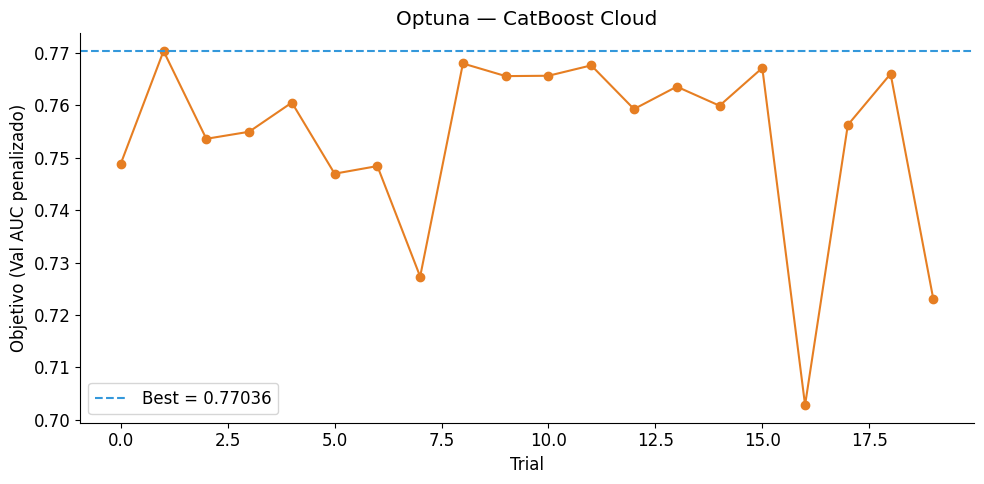

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(trial_df['number'], trial_df['value'], 'o-', color='#e67e22', ms=6)
ax.axhline(study.best_value, color='#3498db', ls='--',
           label=f'Best = {study.best_value:.5f}')
ax.set_xlabel('Trial')
ax.set_ylabel('Objetivo (Val AUC penalizado)')
ax.set_title('Optuna — CatBoost Cloud')
ax.legend()
plt.tight_layout()
plt.savefig(MODEL_DIR / 'optuna_history.png', dpi=120)
plt.show()

## 2. Modelo Final — Refit en Train Completo

In [10]:
params_final = dict(
    iterations         = best_n_iter,
    auto_class_weights = 'Balanced',
    eval_metric        = 'AUC',
    task_type          = 'GPU' if USE_GPU else 'CPU',
    random_seed        = SEED,
    verbose            = 100,
    **study.best_params
)

print('=' * 65)
print('Entrenando modelo final en train completo...')
print(f'  Iteraciones : {best_n_iter}')
print(f'  Device      : {"GPU" if USE_GPU else "CPU"}')
print('=' * 65)

t0 = time.time()
model = CatBoostClassifier(**params_final)
model.fit(X, y)
elapsed = time.time() - t0
print(f'Entrenamiento finalizado en {elapsed:.0f}s ✓')

Entrenando modelo final en train completo...
  Iteraciones : 628
  Device      : GPU


Default metric period is 5 because AUC is/are not implemented for GPU


0:	total: 5.43ms	remaining: 3.4s
100:	total: 459ms	remaining: 2.39s
200:	total: 894ms	remaining: 1.9s
300:	total: 1.35s	remaining: 1.47s
400:	total: 1.81s	remaining: 1.03s
500:	total: 2.25s	remaining: 571ms
600:	total: 2.72s	remaining: 122ms
627:	total: 2.83s	remaining: 0us
Entrenamiento finalizado en 3s ✓


## 3. Métricas sobre Train Completo

In [11]:
y_prob_train = model.predict_proba(X)[:, 1]
metrics      = compute_metrics(y, y_prob_train, threshold=0.5, label='CatBoost Cloud')
metrics['Val_AUC']  = round(study.best_trial.user_attrs['val_auc'], 5)
metrics['n_iter']   = best_n_iter

print('=' * 65)
print('CATBOOST CLOUD — MÉTRICAS FINALES')
print('=' * 65)
print(f'  Train AUC       : {metrics["AUC"]}')
print(f'  Val AUC (Optuna): {metrics["Val_AUC"]}  (split 80/20)')
print(f'  Obj penalizado  : {study.best_value:.5f}')
print(f'  Gap Train - Val : {metrics["AUC"] - metrics["Val_AUC"]:.5f}')
print(f'  n_iterations    : {metrics["n_iter"]}')
print(f'  Recall          : {metrics["Recall"]}')
print(f'  Precision       : {metrics["Precision"]}')
print(f'  F1              : {metrics["F1"]}')
print(f'  TP/TN/FP/FN     : {metrics["TP"]} / {metrics["TN"]} / {metrics["FP"]} / {metrics["FN"]}')
print('=' * 65)

display(pd.DataFrame([metrics]).set_index('Model'))

CATBOOST CLOUD — MÉTRICAS FINALES
  Train AUC       : 0.788
  Val AUC (Optuna): 0.77666  (split 80/20)
  Obj penalizado  : 0.77036
  Gap Train - Val : 0.01134
  n_iterations    : 628
  Recall          : 0.7152
  Precision       : 0.1803
  F1              : 0.288
  TP/TN/FP/FN     : 17755 / 201972 / 80714 / 7070


,AUC,N,P,TP,TN,FP,FN,Recall,Precision,F1,Val_AUC,n_iter
Model,,,,,,,,,,,,
CatBoost Cloud,0.788,307511,98469,17755,201972,80714,7070,0.7152,0.1803,0.288,0.77666,628


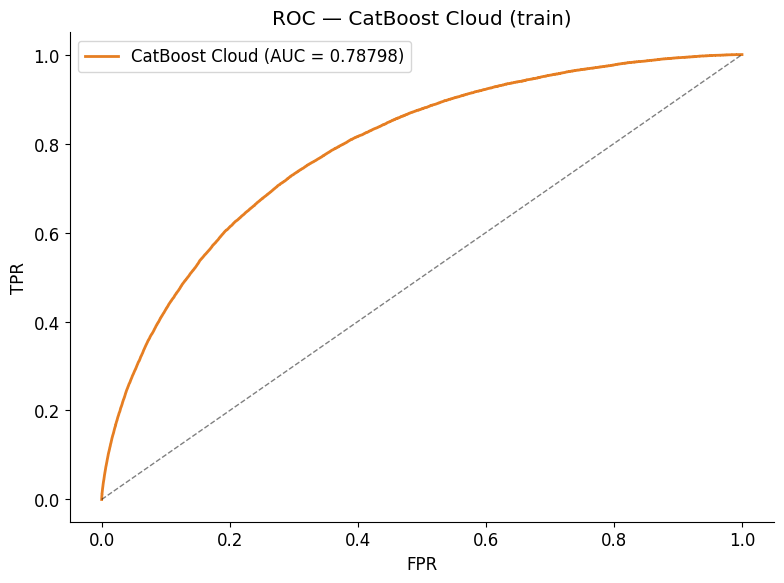

In [12]:
fpr, tpr, _ = roc_curve(y, y_prob_train)
auc_val      = roc_auc_score(y, y_prob_train)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color='#e67e22', lw=2, label=f'CatBoost Cloud (AUC = {auc_val:.5f})')
ax.plot([0,1],[0,1],'k--',lw=1,alpha=0.5)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC — CatBoost Cloud (train)')
ax.legend()
plt.tight_layout()
plt.savefig(MODEL_DIR / 'roc_curve.png', dpi=120)
plt.show()

## 4. Importancia de Variables

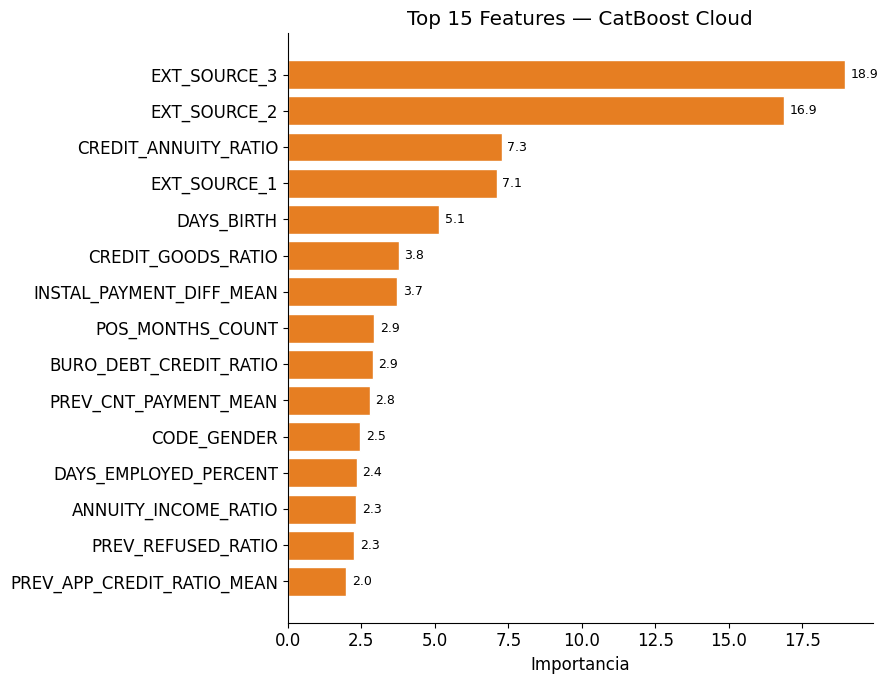

,feature,importance
0,EXT_SOURCE_3,18.948163
1,EXT_SOURCE_2,16.887796
2,CREDIT_ANNUITY_RATIO,7.270441
3,EXT_SOURCE_1,7.104815
4,DAYS_BIRTH,5.147550
5,CREDIT_GOODS_RATIO,3.769615
6,INSTAL_PAYMENT_DIFF_MEAN,3.728645
7,POS_MONTHS_COUNT,2.941405
8,BURO_DEBT_CREDIT_RATIO,2.889913
9,PREV_CNT_PAYMENT_MEAN,2.787170


In [13]:
importance  = model.get_feature_importance()
feat_imp_df = pd.DataFrame({'feature': feature_cols, 'importance': importance})
feat_imp_df = feat_imp_df.sort_values('importance', ascending=False)

top15 = feat_imp_df.head(15)
fig, ax = plt.subplots(figsize=(9, 7))
bars = ax.barh(top15['feature'][::-1], top15['importance'][::-1],
               color='#e67e22', edgecolor='white')
ax.set_xlabel('Importancia')
ax.set_title('Top 15 Features — CatBoost Cloud')
for bar, val in zip(bars, top15['importance'][::-1]):
    ax.text(bar.get_width() + top15['importance'].max()*0.01,
            bar.get_y() + bar.get_height()/2,
            f'{val:.1f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig(MODEL_DIR / 'feature_importance.png', dpi=120)
plt.show()
display(feat_imp_df.reset_index(drop=True))

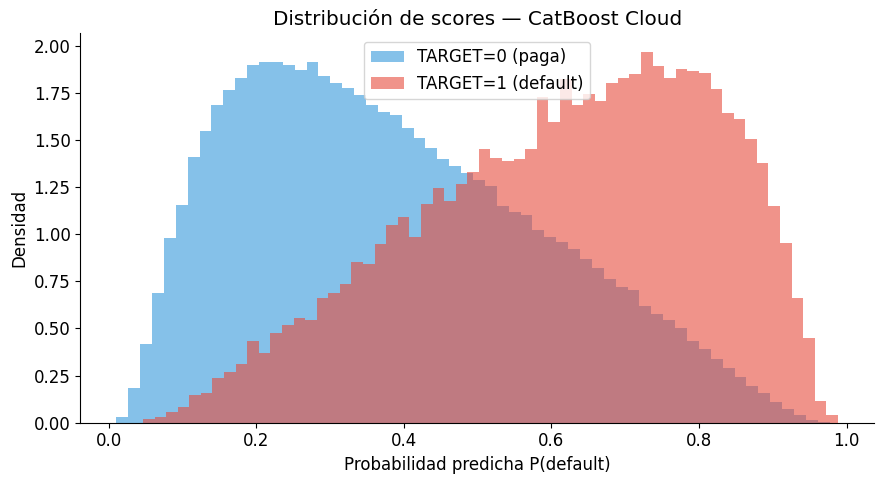

In [14]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(y_prob_train[y == 0], bins=60, alpha=0.6, color='#3498db',
        label='TARGET=0 (paga)', density=True)
ax.hist(y_prob_train[y == 1], bins=60, alpha=0.6, color='#e74c3c',
        label='TARGET=1 (default)', density=True)
ax.set_xlabel('Probabilidad predicha P(default)')
ax.set_ylabel('Densidad')
ax.set_title('Distribución de scores — CatBoost Cloud')
ax.legend()
plt.tight_layout()
plt.savefig(MODEL_DIR / 'score_distribution.png', dpi=120)
plt.show()

## 5. Guardar Modelo y Metadata

In [15]:
model_path = MODEL_DIR / 'catboost_cloud_best.cbm'
model.save_model(str(model_path))

metadata = {
    'best_params'      : {k: float(v) if isinstance(v, (int, float)) else v
                          for k, v in study.best_params.items()},
    'best_n_rounds'    : int(best_n_iter),      # usado por predict notebook
    'best_n_iter'      : int(best_n_iter),
    'best_cv_auc'      : float(study.best_trial.user_attrs['val_auc']),  # val AUC real
    'best_obj_auc'     : float(study.best_value),                         # obj penalizado
    'train_auc'        : float(metrics['AUC']),
    'feature_cols'     : list(feature_cols),
    'n_trials'         : N_TRIALS,
    'early_stop'       : EARLY_STOP,
    'use_gpu'          : USE_GPU,
    'catboost_version' : catboost.__version__,
    'timestamp'        : pd.Timestamp.now().isoformat()
}

meta_path = MODEL_DIR / 'catboost_cloud_metadata.json'
with open(meta_path, 'w') as f:
    json.dump(metadata, f, indent=2)

print('=' * 65)
print('ARTEFACTOS GUARDADOS')
print('=' * 65)
print(f'  {model_path.name:<40} ({model_path.stat().st_size/1e6:.2f} MB)')
print(f'  {meta_path.name}')
print(f'  optuna_trials.csv')
print('=' * 65)
print('\n>>> Descargar desde el Output tab de Kaggle:')
print(f'    - {model_path.name}')
print(f'    - {meta_path.name}')
print(f'    - optuna_trials.csv')
print('\n>>> Luego correr localmente: catboost_cloud_predict.ipynb')

ARTEFACTOS GUARDADOS
  catboost_cloud_best.cbm                  (0.21 MB)
  catboost_cloud_metadata.json
  optuna_trials.csv

>>> Descargar desde el Output tab de Kaggle:
    - catboost_cloud_best.cbm
    - catboost_cloud_metadata.json
    - optuna_trials.csv

>>> Luego correr localmente: catboost_cloud_predict.ipynb


## Resumen Final

In [16]:
print('=' * 65)
print('CATBOOST CLOUD — RESUMEN')
print('=' * 65)
print('Hiperparámetros óptimos (Optuna):')
for k, v in study.best_params.items():
    print(f'  {k:<24}: {v}')
print(f'  {"n_iterations":<24}: {best_n_iter}  (via early stopping)')
print('\nMétricas:')
print(f'  Train AUC        : {metrics["AUC"]}')
print(f'  Val AUC (80/20)  : {metrics["Val_AUC"]}')
print(f'  Obj penalizado   : {study.best_value:.5f}')
print(f'  Gap Train - Val  : {metrics["AUC"] - metrics["Val_AUC"]:.5f}')
print(f'  Recall           : {metrics["Recall"]}')
print(f'  Precision        : {metrics["Precision"]}')
print(f'  F1               : {metrics["F1"]}')
print('\nEntorno:')
print(f'  CatBoost version : {catboost.__version__}')
print(f'  GPU usado        : {USE_GPU}')
print(f'  Timestamp        : {metadata["timestamp"]}')
print('=' * 65)

CATBOOST CLOUD — RESUMEN
Hiperparámetros óptimos (Optuna):
  bootstrap_type          : Bayesian
  learning_rate           : 0.11114989443094977
  depth                   : 4
  l2_leaf_reg             : 27.08160864249967
  random_strength         : 2.1368329072358767
  bagging_temperature     : 2.1233911067827616
  n_iterations            : 628  (via early stopping)

Métricas:
  Train AUC        : 0.788
  Val AUC (80/20)  : 0.77666
  Obj penalizado   : 0.77036
  Gap Train - Val  : 0.01134
  Recall           : 0.7152
  Precision        : 0.1803
  F1               : 0.288

Entorno:
  CatBoost version : 1.2.8
  GPU usado        : True
  Timestamp        : 2026-02-25T16:33:01.142863
